# Explore the Yelp dataset for SiteSense

## Goal

Download [Yelp-JSON.zip from Google Drive](https://drive.google.com/file/d/1cyir0oGMviwUjXPtMhvxpX27TQL2Lg6y/view?usp=sharing),
audit business and check-in coverage, inspect a small review sample, and experiment with
two seasonal baselines for one business. The archive is approximately **4.35 GB**.

Check-ins are **recorded activity**, not unique visitors, sales, or revenue. This notebook
does not join weather or establish that weather causes activity changes. Review samples
are taken from the start of the file and are not representative random samples.

Run cells from top to bottom. Edit the parameters to change the city, category, business,
review sample size, or temporal holdout. The ZIP and working files stay under `data/raw/`; tables and an
experiment manifest stay under `data/processed/`. All of these data files are ignored by Git.

## Setup

From the repository root:

```sh
uv sync --frozen --group notebooks
uv run --frozen --group notebooks jupyter lab --notebook-dir=.
```

In VS Code, select `.venv/bin/python` as the notebook kernel.
On Google Colab, upload this notebook and run `%pip install gdown pandas matplotlib`
in a separate cell before continuing. Colab's local files disappear when its runtime ends;
use the archive-path parameter below if you already have a persistent copy.

You need approximately 5 GB of free disk space for the download and small outputs.
The notebook supports JSON files in the ZIP or in a compressed TAR inside it. It stages
business/check-in JSON and a review prefix, without extracting the full dataset.
The first download can take several minutes. Reruns reuse the completed ZIP.

In [1]:
import hashlib
import json
import os
import platform
import shutil
import tarfile
import zipfile
from datetime import UTC, datetime
from importlib.metadata import version
from itertools import islice
from pathlib import Path

import gdown
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 14)
pd.set_option("display.max_colwidth", 60)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.25})
print({package: version(package) for package in ("gdown", "pandas", "matplotlib")})

{'gdown': '6.4.1', 'pandas': '3.0.6', 'matplotlib': '3.11.2'}


### Choose your experiment

`ARCHIVE_PATH` can point to a manually downloaded ZIP. Set `EXPECTED_ARCHIVE_BYTES = None`
when intentionally using another dataset version. `BUSINESS_ID = None` selects the business
with the most timestamp entries in the chosen city/category; set an ID to inspect another.

The business and check-in summaries scan their complete files. Reviews are bounded by
`REVIEW_SAMPLE_ROWS`; the user and tip tables are listed but never loaded into dataframes.

In [2]:
PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").is_file()
        and (path / "notebooks/01_yelp_dataset_exploration.ipynb").is_file()
    ),
    Path.cwd(),
)
RAW_DIR = PROJECT_ROOT / "data/raw"
STAGING_DIR = RAW_DIR / "yelp_exploration"
OUTPUT_DIR = PROJECT_ROOT / "data/processed/yelp_exploration"
RAW_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DRIVE_FILE_ID = "1cyir0oGMviwUjXPtMhvxpX27TQL2Lg6y"
SOURCE_URL = f"https://drive.google.com/file/d/{DRIVE_FILE_ID}/view"
ARCHIVE_PATH = Path(os.environ.get("SITESENSE_YELP_ARCHIVE", RAW_DIR / "Yelp-JSON.zip"))
# Size observed in Drive metadata on 2026-10-05; change for a different archive version.
EXPECTED_ARCHIVE_BYTES = None if os.environ.get("SITESENSE_YELP_ARCHIVE") else 4_345_335_132
COMPUTE_SHA256 = True

CITY = "Philadelphia"
STATE = "PA"
CATEGORY = "Restaurants"  # Exact Yelp category, or None to include all categories.
BUSINESS_ID = None
REVIEW_SAMPLE_ROWS = 10_000
HOLDOUT_FRACTION = 0.20
MIN_TRAIN_DAYS = 56
MIN_TEST_DAYS = 14

assert REVIEW_SAMPLE_ROWS > 0
assert 0 < HOLDOUT_FRACTION < 1
print(f"Archive: {ARCHIVE_PATH}")
print(f"Outputs: {OUTPUT_DIR}")

Archive: /Users/hoadx/Workspace/mse/sitesense/data/raw/Yelp-JSON.zip
Outputs: /Users/hoadx/Workspace/mse/sitesense/data/processed/yelp_exploration


## Steps

### 1. Download and verify the archive

`gdown` handles Drive's large-file confirmation and resumes its `.part` file after an
interruption. If Drive blocks anonymous downloads, open the source link, download the ZIP
manually, and put it at `ARCHIVE_PATH`, then rerun this cell. No Drive credentials are saved.

The size check detects a wrong/incomplete cached file. A local SHA-256 identifies the bytes
used in this experiment; there is no trusted source digest here to authenticate them.

In [3]:
if not ARCHIVE_PATH.exists():
    ARCHIVE_PATH.parent.mkdir(parents=True, exist_ok=True)
    required_space = (EXPECTED_ARCHIVE_BYTES or 4_345_335_132) + 512 * 1024**2
    partial_bytes = sum(
        path.stat().st_size for path in ARCHIVE_PATH.parent.glob(f"{ARCHIVE_PATH.name}*.part")
    )
    if shutil.disk_usage(ARCHIVE_PATH.parent).free < max(0, required_space - partial_bytes):
        raise OSError("Not enough disk space for the ZIP. Free space or change ARCHIVE_PATH.")
    downloaded = gdown.download(
        id=DRIVE_FILE_ID, output=str(ARCHIVE_PATH), resume=True, use_cookies=False
    )
    if downloaded is None:
        raise RuntimeError(f"Download failed. Download manually from {SOURCE_URL}.")
else:
    print("Reusing the local archive.")

archive_bytes = ARCHIVE_PATH.stat().st_size
if EXPECTED_ARCHIVE_BYTES is not None and archive_bytes != EXPECTED_ARCHIVE_BYTES:
    raise ValueError(
        f"ZIP size mismatch: {archive_bytes:,} vs expected {EXPECTED_ARCHIVE_BYTES:,} bytes. "
        "Check the download; use EXPECTED_ARCHIVE_BYTES=None only for a known different version."
    )
if not zipfile.is_zipfile(ARCHIVE_PATH):
    raise ValueError("The downloaded file is not a ZIP. Check for a Drive HTML error page.")

archive_sha256 = None
if COMPUTE_SHA256:
    digest = hashlib.sha256()
    with ARCHIVE_PATH.open("rb") as stream:
        for chunk in iter(lambda: stream.read(8 * 1024**2), b""):
            digest.update(chunk)
    archive_sha256 = digest.hexdigest()
print(f"ZIP size: {archive_bytes / 1e9:.2f} GB; SHA-256: {archive_sha256 or 'skipped'}")

Reusing the local archive.
ZIP size: 4.35 GB; SHA-256: 47dd6e4d279ac9d8734ddc30bfb3d78e571b9df4bb95923d7acf9a6ef3d8a4ab


### 2. Inspect the archive and stage the tables we need

This shared ZIP wraps a gzip-compressed `yelp_dataset.tar`. Scan the nested archive once,
saving the complete business/check-in tables and only a bounded prefix of reviews. A small
manifest reuses these working files when the archive and sample-size parameter match.
ZIPs containing JSON directly are also supported. Original member paths are never used as
output paths, and links are never extracted. Staging takes a few minutes on the first run.

The inventory distinguishes the outer ZIP from inner TAR members. The full ZIP is read
during nested staging, but bounded review reads do not audit every JSON object in that table.

In [4]:
with zipfile.ZipFile(ARCHIVE_PATH) as archive:
    inventory = pd.DataFrame(
        [
            {
                "member": member.filename,
                "compressed_mb": member.compress_size / 1e6,
                "uncompressed_mb": member.file_size / 1e6,
            }
            for member in archive.infolist()
            if not member.is_dir()
        ]
    )
display(inventory.round(2))
print(f"Total uncompressed size: {inventory.uncompressed_mb.sum() / 1000:.2f} GB")

,member,compressed_mb,uncompressed_mb
0,Yelp JSON/Yelp Dataset Documentation & ToS copy.pdf,0.11,0.12
1,__MACOSX/Yelp JSON/._Yelp Dataset Documentation & ToS co...,0.00,0.00
2,Yelp JSON/yelp_dataset.tar,4345.22,4343.89
3,__MACOSX/Yelp JSON/._yelp_dataset.tar,0.00,0.00


Total uncompressed size: 4.34 GB


In [5]:
tables = ("business", "checkin", "review")
staged_paths = {table: STAGING_DIR / f"{table}.jsonl" for table in tables}
STAGING_DIR.mkdir(parents=True, exist_ok=True)
staging_manifest_path = STAGING_DIR / "staging_manifest.json"
staging_key = {
    "archive_path": str(ARCHIVE_PATH.resolve()),
    "archive_sha256": archive_sha256,
    "archive_bytes": archive_bytes,
    "archive_mtime_ns": ARCHIVE_PATH.stat().st_mtime_ns,
    "review_sample_rows": REVIEW_SAMPLE_ROWS,
    "staging_version": 1,
}
cached = None
if staging_manifest_path.is_file():
    try:
        candidate = json.loads(staging_manifest_path.read_text())
        if candidate.get("key") == staging_key and all(
            path.is_file() and path.stat().st_size == candidate.get("staged_bytes", {}).get(table)
            for table, path in staged_paths.items()
        ):
            cached = candidate
    except json.JSONDecodeError:
        pass  # An interrupted/invalid staging manifest is rebuilt below.


def table_for_member(name):
    if name.startswith("__MACOSX/"):
        return None
    for table in tables:
        if Path(name).name.lower() in {
            f"yelp_academic_dataset_{table}.json",
            f"{table}.json",
            f"{table}.jsonl",
        }:
            return table
    return None


members = {}
inner_inventory = []


def stage_table(table, member_name, binary):
    if table in members:
        raise ValueError(f"Duplicate {table} members; inspect archive before choosing a source.")
    temporary_path = staged_paths[table].with_suffix(".partial")
    with temporary_path.open("wb") as output:
        if table == "review":
            nonempty_lines = (line for line in binary if line.strip())
            for line in islice(nonempty_lines, REVIEW_SAMPLE_ROWS):
                output.write(line)
        else:
            shutil.copyfileobj(binary, output, length=8 * 1024**2)
    temporary_path.replace(staged_paths[table])
    members[table] = member_name
    print(f"Staged {table}: {staged_paths[table].stat().st_size / 1e6:.1f} MB", flush=True)

In [6]:
if cached:
    members = cached["members"]
    inner_inventory = cached["inner_inventory"]
    print("Reusing staged JSON tables.")
else:
    with zipfile.ZipFile(ARCHIVE_PATH) as archive:
        direct_members = [
            member
            for member in archive.infolist()
            if not member.is_dir() and table_for_member(member.filename)
        ]
        if direct_members:
            for member in direct_members:
                with archive.open(member) as binary:
                    stage_table(table_for_member(member.filename), member.filename, binary)
        else:
            nested_members = [
                member
                for member in archive.infolist()
                if not member.filename.startswith("__MACOSX/")
                and member.filename.lower().endswith((".tar", ".tar.gz", ".tgz"))
            ]
            if len(nested_members) != 1:
                raise ValueError(
                    "Expected JSON tables or one nested TAR. Inspect the ZIP inventory."
                )
            with archive.open(nested_members[0]) as binary:
                with tarfile.open(fileobj=binary, mode="r|*") as inner:
                    for member in inner:
                        if not member.isfile():
                            continue
                        inner_inventory.append(
                            {"member": member.name, "uncompressed_mb": member.size / 1e6}
                        )
                        table = table_for_member(member.name)
                        if table:
                            with inner.extractfile(member) as source:
                                stage_table(table, member.name, source)
                # Consume remaining ZIP bytes, including any trailer, for its CRC check.
                for _ in iter(lambda: binary.read(8 * 1024**2), b""):
                    pass
    if set(members) != set(tables):
        raise ValueError(f"Missing required tables: {set(tables) - set(members)}")
    cached = {
        "key": staging_key,
        "members": members,
        "inner_inventory": inner_inventory,
        "staged_bytes": {table: path.stat().st_size for table, path in staged_paths.items()},
    }
    staging_manifest_path.write_text(json.dumps(cached, indent=2))

if inner_inventory:
    display(pd.DataFrame(inner_inventory).round(2))
display(pd.Series(members, name="Source member").to_frame())


def records(table, limit=None):
    with staged_paths[table].open(encoding="utf-8-sig") as stream:
        nonempty_lines = (line for line in stream if line.strip())
        lines = nonempty_lines if limit is None else islice(nonempty_lines, limit)
        for row_number, line in enumerate(lines, start=1):
            try:
                record = json.loads(line)
            except json.JSONDecodeError as error:
                raise ValueError(f"Invalid JSON in {table}, record {row_number}") from error
            if not isinstance(record, dict):
                raise ValueError(f"Expected a JSON object in {table}, record {row_number}")
            yield record


display({table: list(next(records(table)).keys()) for table in members})

Reusing staged JSON tables.


,member,uncompressed_mb
0,Dataset_User_Agreement.pdf,0.08
1,yelp_academic_dataset_business.json,118.86
2,yelp_academic_dataset_checkin.json,286.96
3,yelp_academic_dataset_review.json,5341.87
4,yelp_academic_dataset_tip.json,180.60
5,yelp_academic_dataset_user.json,3363.33


,Source member
business,yelp_academic_dataset_business.json
checkin,yelp_academic_dataset_checkin.json
review,yelp_academic_dataset_review.json


{'business': ['business_id',
  'name',
  'address',
  'city',
  'state',
  'postal_code',
  'latitude',
  'longitude',
  'stars',
  'review_count',
  'is_open',
  'attributes',
  'categories',
  'hours'],
 'checkin': ['business_id', 'date'],
 'review': ['review_id',
  'user_id',
  'business_id',
  'stars',
  'useful',
  'funny',
  'cool',
  'text',
  'date']}

### 3. Load business metadata and audit quality

Keep scalar fields and categories; nested `attributes`/`hours` stay in the source.
Missing values, duplicate IDs, and impossible coordinates affect coverage and joins.

In [7]:
business_fields = [
    "business_id",
    "name",
    "city",
    "state",
    "latitude",
    "longitude",
    "stars",
    "review_count",
    "is_open",
    "categories",
]
business = pd.DataFrame(
    ({field: record.get(field) for field in business_fields} for record in records("business")),
    columns=business_fields,
)
if business.empty or business.business_id.isna().any() or business.business_id.duplicated().any():
    raise ValueError("Business IDs must be present and unique for a reliable join.")
for field in ("latitude", "longitude", "stars", "review_count", "is_open"):
    business[field] = pd.to_numeric(business[field], errors="coerce")

quality = pd.DataFrame(
    {
        "dtype": business.dtypes.astype(str),
        "missing_rows": business.isna().sum(),
        "missing_percent": business.isna().mean().mul(100).round(2),
    }
)
display(quality)
display(business.head(5))
invalid_coordinates = ~(business.latitude.between(-90, 90) & business.longitude.between(-180, 180))
print(
    f"Businesses: {len(business):,}; invalid/missing coordinate rows: {invalid_coordinates.sum():,}"
)
print(f"Missing category rows: {business.categories.isna().sum():,}")

,dtype,missing_rows,missing_percent
business_id,str,0,0.00
name,str,0,0.00
city,str,0,0.00
state,str,0,0.00
latitude,float64,0,0.00
longitude,float64,0,0.00
stars,float64,0,0.00
review_count,int64,0,0.00
is_open,int64,0,0.00
categories,str,103,0.07


,business_id,name,city,state,latitude,longitude,stars,review_count,is_open,categories
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ",Santa Barbara,CA,34.426679,-119.711197,5.0,7,0,"Doctors, Traditional Chinese Medicine, Naturopathic/Holi..."
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,Affton,MO,38.551126,-90.335695,3.0,15,1,"Shipping Centers, Local Services, Notaries, Mailbox Cent..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,Tucson,AZ,32.223236,-110.880452,3.5,22,0,"Department Stores, Shopping, Fashion, Home & Garden, Ele..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,Philadelphia,PA,39.955505,-75.155564,4.0,80,1,"Restaurants, Food, Bubble Tea, Coffee & Tea, Bakeries"
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,Green Lane,PA,40.338183,-75.471659,4.5,13,1,"Brewpubs, Breweries, Food"


Businesses: 150,346; invalid/missing coordinate rows: 0
Missing category rows: 103


### 4. Explore geographic and category coverage

Dataset coverage can reflect collection choices. More listed businesses or check-ins
do not by themselves identify the best retail market. Category counts overlap because
a business can belong to multiple categories.

,,businesses,median_stars,listed_open_share
state,city,,,
PA,Philadelphia,14567,4.0,0.724
AZ,Tucson,9249,3.5,0.814
FL,Tampa,9048,4.0,0.798
IN,Indianapolis,7540,4.0,0.782
TN,Nashville,6968,4.0,0.774
LA,New Orleans,6208,4.0,0.749
NV,Reno,5932,4.0,0.802
AB,Edmonton,5054,3.5,0.775
MO,Saint Louis,4827,3.5,0.705


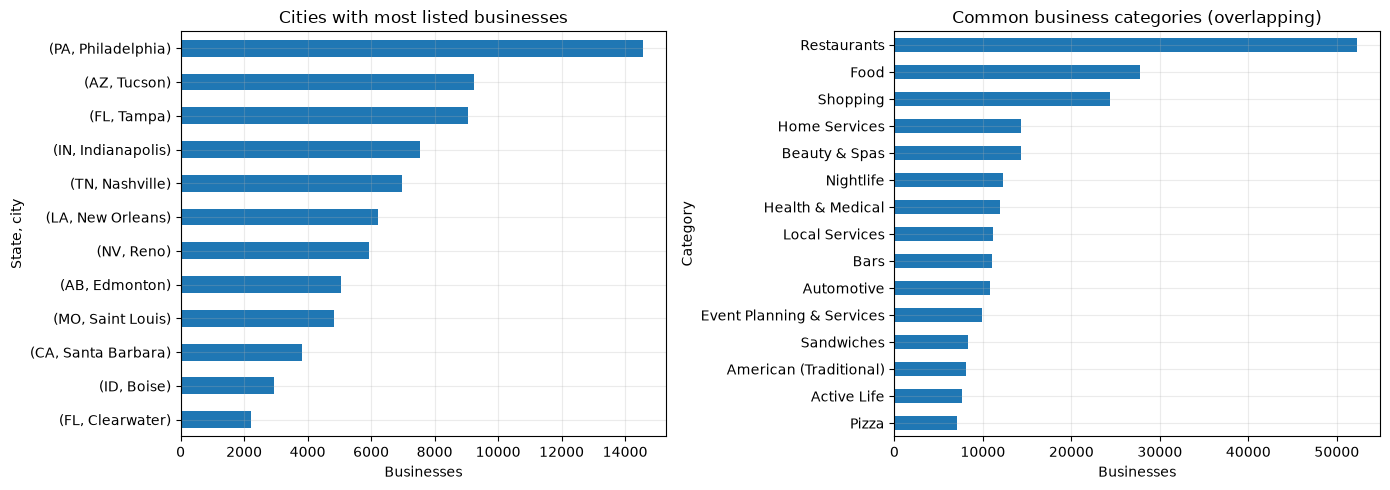

In [8]:
business["category_list"] = business.categories.fillna("").map(
    lambda value: [category.strip() for category in value.split(",") if category.strip()]
)
city_coverage = (
    business.groupby(["state", "city"], dropna=False)
    .agg(
        businesses=("business_id", "size"),
        median_stars=("stars", "median"),
        listed_open_share=("is_open", "mean"),
    )
    .sort_values("businesses", ascending=False)
)
display(city_coverage.head(15).round(3))
top_categories = business.category_list.explode().dropna().value_counts().head(15)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
city_coverage.head(12).businesses.sort_values().plot.barh(ax=axes[0])
axes[0].set(title="Cities with most listed businesses", xlabel="Businesses", ylabel="State, city")
top_categories.sort_values().plot.barh(ax=axes[1])
axes[1].set(
    title="Common business categories (overlapping)", xlabel="Businesses", ylabel="Category"
)
plt.tight_layout()
plt.show()

### 5. Summarize recorded check-in activity

Scan one JSON object per business, counting comma-separated timestamp entries without
expanding them into one enormous table. A missing check-in record remains distinct from
a record with zero entries. Dates are parsed more carefully for the selected business below.

In [9]:
checkin_rows = []
for record in records("checkin"):
    dates = record.get("date") or ""
    checkin_rows.append(
        {
            "business_id": record.get("business_id"),
            "timestamp_entries": sum(bool(token.strip()) for token in dates.split(",")),
        }
    )
checkin = pd.DataFrame(checkin_rows, columns=["business_id", "timestamp_entries"])
if checkin.business_id.isna().any() or checkin.business_id.duplicated().any():
    raise ValueError("Check-in IDs must be present and unique; inspect source before joining.")

unmatched_checkin = ~checkin.business_id.isin(business.business_id)
print(f"Check-in rows without business metadata: {unmatched_checkin.sum():,}")
business_activity = business.merge(checkin, how="left", on="business_id", validate="one_to_one")
business_activity["has_checkin_record"] = business_activity.timestamp_entries.notna()
activity_coverage = business_activity.groupby(["state", "city"], dropna=False).agg(
    businesses=("business_id", "size"),
    businesses_with_checkin_records=("has_checkin_record", "sum"),
    timestamp_entries=("timestamp_entries", "sum"),
)
activity_coverage["checkin_record_share"] = (
    activity_coverage.businesses_with_checkin_records / activity_coverage.businesses
)
display(activity_coverage.sort_values("timestamp_entries", ascending=False).head(15).round(3))
display(business_activity.timestamp_entries.describe(percentiles=[0.5, 0.9, 0.99]).to_frame())

Check-in rows without business metadata: 0


,,businesses,businesses_with_checkin_records,timestamp_entries,checkin_record_share
state,city,,,,
PA,Philadelphia,14567,12891,1836160.0,0.885
LA,New Orleans,6208,5866,1486452.0,0.945
FL,Tampa,9048,8003,918172.0,0.885
IN,Indianapolis,7540,6915,886001.0,0.917
TN,Nashville,6968,6177,817258.0,0.886
AZ,Tucson,9249,7880,772140.0,0.852
NV,Reno,5932,5096,712285.0,0.859
MO,Saint Louis,4827,4369,638978.0,0.905
CA,Santa Barbara,3829,2989,507626.0,0.781


,timestamp_entries
count,131930.000000
mean,101.242136
std,417.132327
min,1.000000
50%,20.000000
90%,229.000000
99%,1282.000000
max,52144.000000


### 6. Inspect a bounded review sample

Read only the first `REVIEW_SAMPLE_ROWS` reviews. This prefix is convenient for learning
the schema, but its rating distribution is not an estimate for all Yelp reviews. Retain
text length rather than displaying review text or user identities.

,business_id,stars,date,text_characters,useful
0,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,2018-07-07 22:09:11,513,0
1,7ATYjTIgM3jUlt4UM3IypQ,5.0,2012-01-03 15:28:18,829,1
2,YjUWPpI6HXG530lwP-fb2A,3.0,2014-02-05 20:30:30,339,0
3,kxX2SOes4o-D3ZQBkiMRfA,5.0,2015-01-04 00:01:03,243,1
4,e4Vwtrqf-wpJfwesgvdgxQ,4.0,2017-01-14 20:54:15,534,1


,stars,text_characters,useful
count,10000.00,10000.00,10000.00
mean,3.85,549.04,0.89
std,1.35,504.44,2.09
min,1.00,26.00,0.00
25%,3.00,224.00,0.00
50%,4.00,395.00,0.00
75%,5.00,694.25,1.00
max,5.00,4994.00,91.00


Prefix sample: 10,000 rows; duplicate IDs: 0
Unparseable review dates: 0
Sample date range: 2005-03-01 17:47:15 to 2018-10-04 18:22:35


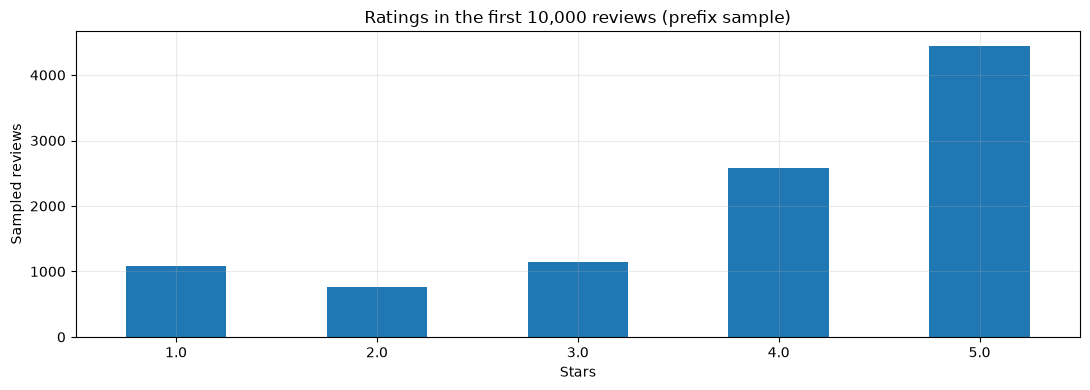

In [10]:
reviews = pd.DataFrame(
    [
        {
            "review_id": record.get("review_id"),
            "business_id": record.get("business_id"),
            "stars": record.get("stars"),
            "date": record.get("date"),
            "text_characters": len(record.get("text") or ""),
            "useful": record.get("useful"),
        }
        for record in records("review", limit=REVIEW_SAMPLE_ROWS)
    ]
)
if reviews.empty:
    raise ValueError("The review file contains no records.")
reviews["date"] = pd.to_datetime(reviews.date, errors="coerce")
reviews["stars"] = pd.to_numeric(reviews.stars, errors="coerce")
display(reviews.drop(columns=["review_id"]).head(5))
display(reviews[["stars", "text_characters", "useful"]].describe().round(2))
print(
    f"Prefix sample: {len(reviews):,} rows; duplicate IDs: {reviews.review_id.duplicated().sum():,}"
)
print(f"Unparseable review dates: {reviews.date.isna().sum():,}")
print(f"Sample date range: {reviews.date.min()} to {reviews.date.max()}")
reviews.stars.value_counts().sort_index().plot.bar(
    title=f"Ratings in the first {len(reviews):,} reviews (prefix sample)",
    xlabel="Stars",
    ylabel="Sampled reviews",
    rot=0,
)
plt.tight_layout()
plt.show()

### 7. Choose a business and build its daily activity series

The default chooses the business with the most entries in the selected city/category.
This deliberate high-activity example is not representative of all businesses. Source
timestamps have no timezone offset; keep them as supplied, without claiming alignment
to local weather. The audit reports unparseable dates and repeated timestamps.

Fill dates **between the first and last recorded event** with zero recorded check-ins;
exclude time outside that span. Zero recorded activity does not establish zero customers,
opening status, or complete data collection. Duplicate timestamps are retained because
the source does not identify whether they represent different check-ins.

In [11]:
eligible = business_activity[business_activity.timestamp_entries.fillna(0).gt(0)].copy()
if BUSINESS_ID is None:
    eligible = eligible[eligible.city.str.casefold().eq(CITY.casefold())]
    if STATE:
        eligible = eligible[eligible.state.str.casefold().eq(STATE.casefold())]
    if CATEGORY:
        eligible = eligible[eligible.category_list.map(lambda categories: CATEGORY in categories)]
else:
    eligible = eligible[eligible.business_id.eq(BUSINESS_ID)]
if eligible.empty:
    raise ValueError(
        "No eligible business. Change CITY, STATE, CATEGORY, or BUSINESS_ID using coverage tables."
    )

selected = eligible.sort_values(["timestamp_entries", "business_id"], ascending=[False, True]).iloc[
    0
]
selected_id = selected.business_id
display(selected.drop(labels=["category_list"]).to_frame("Selected business"))
selected_record = next(
    record for record in records("checkin") if record["business_id"] == selected_id
)
date_tokens = [token.strip() for token in selected_record["date"].split(",") if token.strip()]
timestamps = pd.Series(pd.to_datetime(date_tokens, format="%Y-%m-%d %H:%M:%S", errors="coerce"))
invalid_timestamps = int(timestamps.isna().sum())
repeated_timestamps = int(timestamps.dropna().duplicated().sum())
print(
    f"Unparseable timestamps: {invalid_timestamps:,}; "
    f"repeated timestamps retained: {repeated_timestamps:,}"
)
if timestamps.notna().sum() == 0:
    raise ValueError("The selected business has no parseable check-in timestamps.")

day_counts = timestamps.dropna().dt.normalize().value_counts().sort_index()
observed_days = pd.date_range(day_counts.index.min(), day_counts.index.max(), freq="D")
daily = day_counts.reindex(observed_days, fill_value=0).rename("recorded_checkins").to_frame()
daily.index.name = "date"
daily["weekday"] = daily.index.dayofweek
assert int(daily.recorded_checkins.sum()) == int(timestamps.notna().sum())
assert len(date_tokens) == int(selected.timestamp_entries)
display(daily.head(7))
print(
    f"Observed event span: {daily.index.min().date()} to {daily.index.max().date()}; "
    f"{len(daily):,} days"
)
print(f"Days with zero recorded check-ins: {daily.recorded_checkins.eq(0).mean():.1%}")

,Selected business
business_id,ytynqOUb3hjKeJfRj5Tshw
name,Reading Terminal Market
city,Philadelphia
state,PA
latitude,39.953341
longitude,-75.158855
stars,4.5
review_count,5721
is_open,1
categories,"Candy Stores, Shopping, Department Stores, Fast Food, Be..."


Unparseable timestamps: 0; repeated timestamps retained: 11


,recorded_checkins,weekday
date,,
2010-01-24,1,6
2010-01-25,0,0
2010-01-26,1,1
2010-01-27,1,2
2010-01-28,0,3
2010-01-29,0,4
2010-01-30,0,5


Observed event span: 2010-01-24 to 2022-01-16; 4,376 days
Days with zero recorded check-ins: 13.7%


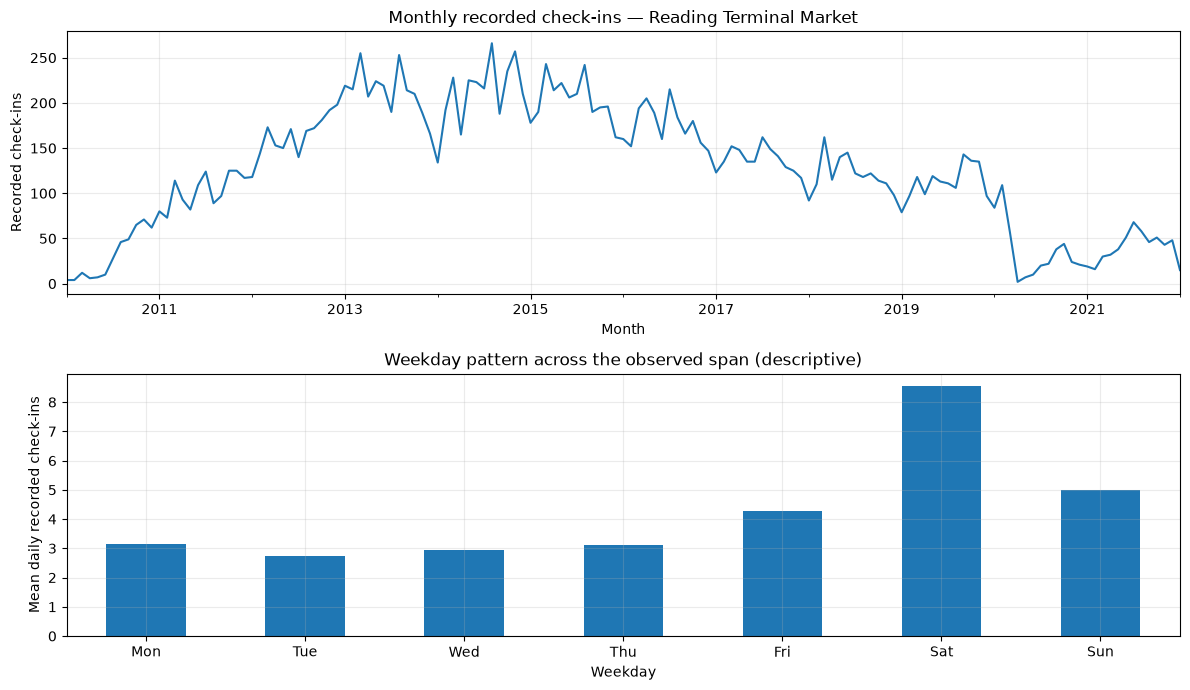

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
daily.recorded_checkins.resample("MS").sum().plot(ax=axes[0])
axes[0].set(
    title=f"Monthly recorded check-ins — {selected['name']}",
    xlabel="Month",
    ylabel="Recorded check-ins",
)
weekday_means = daily.groupby("weekday").recorded_checkins.mean().reindex(range(7))
weekday_means.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekday_means.plot.bar(ax=axes[1], rot=0)
axes[1].set(
    title="Weekday pattern across the observed span (descriptive)",
    xlabel="Weekday",
    ylabel="Mean daily recorded check-ins",
)
plt.tight_layout()
plt.show()

### 8. Experiment with seasonal baselines on a future holdout

Use the earliest days to train and the final `HOLDOUT_FRACTION` to test. Compare a training
weekday mean with a forecast that repeats the final observed training week. Both forecasts
are fixed at the split and never use holdout observations. The global training mean is a
simple reference. Report MAE and RMSE on the **same** holdout dates; avoid percentage errors
because daily counts can be zero.

This tests one chosen business and one temporal split. Selecting a high-activity business
using its full history is useful for exploration but is not a pre-specified population
evaluation. Spatial/event holdouts and weather comparisons remain future work.

Train: 2010-01-24 to 2019-08-24 (3,500 days)
Test: 2019-08-25 to 2022-01-16 (876 days)


,mae,rmse
baseline,,
repeat_last_training_week,3.502,4.271
weekday_mean,3.506,4.140
training_mean,3.612,3.881


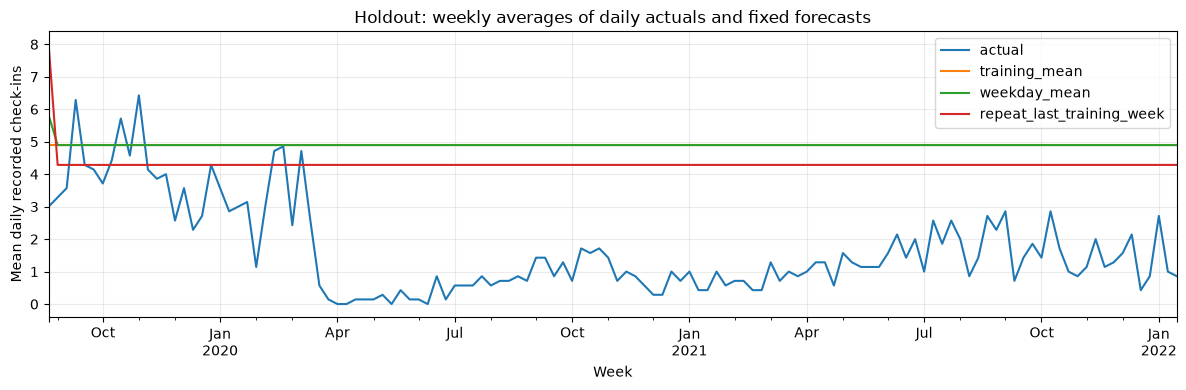

In [13]:
split_position = int(len(daily) * (1 - HOLDOUT_FRACTION))
train = daily.iloc[:split_position].copy()
test = daily.iloc[split_position:].copy()
metrics = pd.DataFrame()
predictions = pd.DataFrame()

if len(train) < MIN_TRAIN_DAYS or len(test) < MIN_TEST_DAYS:
    print(
        f"Baseline skipped: need {MIN_TRAIN_DAYS} training and {MIN_TEST_DAYS} test days; "
        f"have {len(train)} and {len(test)}. Choose a business with a longer event span."
    )
else:
    assert train.index.max() < test.index.min()
    weekday_means_train = train.groupby("weekday").recorded_checkins.mean()
    final_week = train.tail(7).set_index("weekday").recorded_checkins
    assert set(final_week.index) == set(range(7))
    predictions = pd.DataFrame(
        {
            "actual": test.recorded_checkins,
            "training_mean": float(train.recorded_checkins.mean()),
            "weekday_mean": test.weekday.map(weekday_means_train),
            "repeat_last_training_week": test.weekday.map(final_week),
        },
        index=test.index,
    )
    assert predictions.notna().all().all()
    metrics = (
        pd.DataFrame(
            [
                {
                    "baseline": name,
                    "mae": (predictions[name] - predictions.actual).abs().mean(),
                    "rmse": ((predictions[name] - predictions.actual).pow(2).mean()) ** 0.5,
                }
                for name in predictions.columns
                if name != "actual"
            ]
        )
        .set_index("baseline")
        .sort_values("mae")
    )
    print(f"Train: {train.index.min().date()} to {train.index.max().date()} ({len(train):,} days)")
    print(f"Test: {test.index.min().date()} to {test.index.max().date()} ({len(test):,} days)")
    display(metrics.round(3))
    predictions.resample("W").mean().plot(
        title="Holdout: weekly averages of daily actuals and fixed forecasts",
        xlabel="Week",
        ylabel="Mean daily recorded check-ins",
        figsize=(12, 4),
    )
    plt.tight_layout()
    plt.show()

## Checks

Reconcile counts and record source bytes, versions, parameters, missingness, and split
dates alongside the small exported tables. A successful run verifies this exploration,
not dataset representativeness or readiness to score locations. Output files below are
replaced on rerun; copy the output directory before comparing experiments.

In [14]:
assert len(business_activity) == len(business)
matched_entries = business_activity.timestamp_entries.sum()
source_matched_entries = checkin.loc[~unmatched_checkin, "timestamp_entries"].sum()
assert matched_entries == source_matched_entries
assert int(daily.recorded_checkins.sum()) + invalid_timestamps == len(date_tokens)
print(
    "Passed: unique IDs, join row count, matched entry totals, and daily timestamp reconciliation."
)

city_coverage.to_csv(OUTPUT_DIR / "business_city_coverage.csv")
activity_coverage.to_csv(OUTPUT_DIR / "checkin_city_coverage.csv")
daily.to_csv(OUTPUT_DIR / "selected_business_daily_checkins.csv")
# Write even empty results so a skipped experiment cannot leave stale prior metrics.
metrics.to_csv(OUTPUT_DIR / "baseline_metrics.csv")
predictions.to_csv(OUTPUT_DIR / "holdout_predictions.csv")

manifest = {
    "run_at_utc": datetime.now(UTC).isoformat(),
    "source_url": SOURCE_URL,
    "archive_name": ARCHIVE_PATH.name,
    "archive_bytes": archive_bytes,
    "archive_sha256": archive_sha256,
    "python": platform.python_version(),
    "packages": {package: version(package) for package in ("gdown", "pandas", "matplotlib")},
    "members": members,
    "parameters": {
        "city": CITY,
        "state": STATE,
        "category": CATEGORY,
        "requested_business_id": BUSINESS_ID,
        "review_sample_rows": REVIEW_SAMPLE_ROWS,
        "holdout_fraction": HOLDOUT_FRACTION,
        "min_train_days": MIN_TRAIN_DAYS,
        "min_test_days": MIN_TEST_DAYS,
    },
    "business_rows": len(business),
    "checkin_rows": len(checkin),
    "unmatched_checkin_rows": int(unmatched_checkin.sum()),
    "review_rows_sampled": len(reviews),
    "selected_business_id": selected_id,
    "selected_business_name": selected["name"],
    "invalid_selected_timestamps": invalid_timestamps,
    "repeated_selected_timestamps_retained": repeated_timestamps,
    "selected_timestamp_entries": len(date_tokens),
    "selected_event_days": len(daily),
    "train_end": train.index.max().isoformat() if len(train) else None,
    "test_start": test.index.min().isoformat() if len(test) else None,
    "baseline_status": "executed" if not metrics.empty else "skipped_short_series",
    "limitations": [
        "checkins are recorded activity, not customers or revenue",
        "review sample is a file prefix",
        "one selected business and temporal split",
        "source timestamps have no timezone offset",
        "no weather join or causal estimate",
    ],
}
(OUTPUT_DIR / "experiment_manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
display(
    pd.DataFrame({"output": sorted(path.name for path in OUTPUT_DIR.iterdir() if path.is_file())})
)

Passed: unique IDs, join row count, matched entry totals, and daily timestamp reconciliation.


,output
0,baseline_metrics.csv
1,business_city_coverage.csv
2,checkin_city_coverage.csv
3,experiment_manifest.json
4,holdout_predictions.csv
5,selected_business_daily_checkins.csv


## Next Steps

- Change `CITY`, `STATE`, `CATEGORY`, or `BUSINESS_ID`, then rerun from the parameters cell.
- Try several businesses and holdout fractions; compare saved metrics on consistent dates.
- Inspect activity changes, sparse periods, and source coverage before interpreting zero days.
- Establish timestamp timezone semantics before joining daily weather by location and date.
- Compare weather features against the seasonal baselines on identical future holdouts;
  add unseen-business/location and event holdouts before using predictions for rankings.

See the [SiteSense research principles](../docs/architecture.md) and
[Yelp Open Dataset terms](https://www.yelp.com/dataset) before redistributing source data.